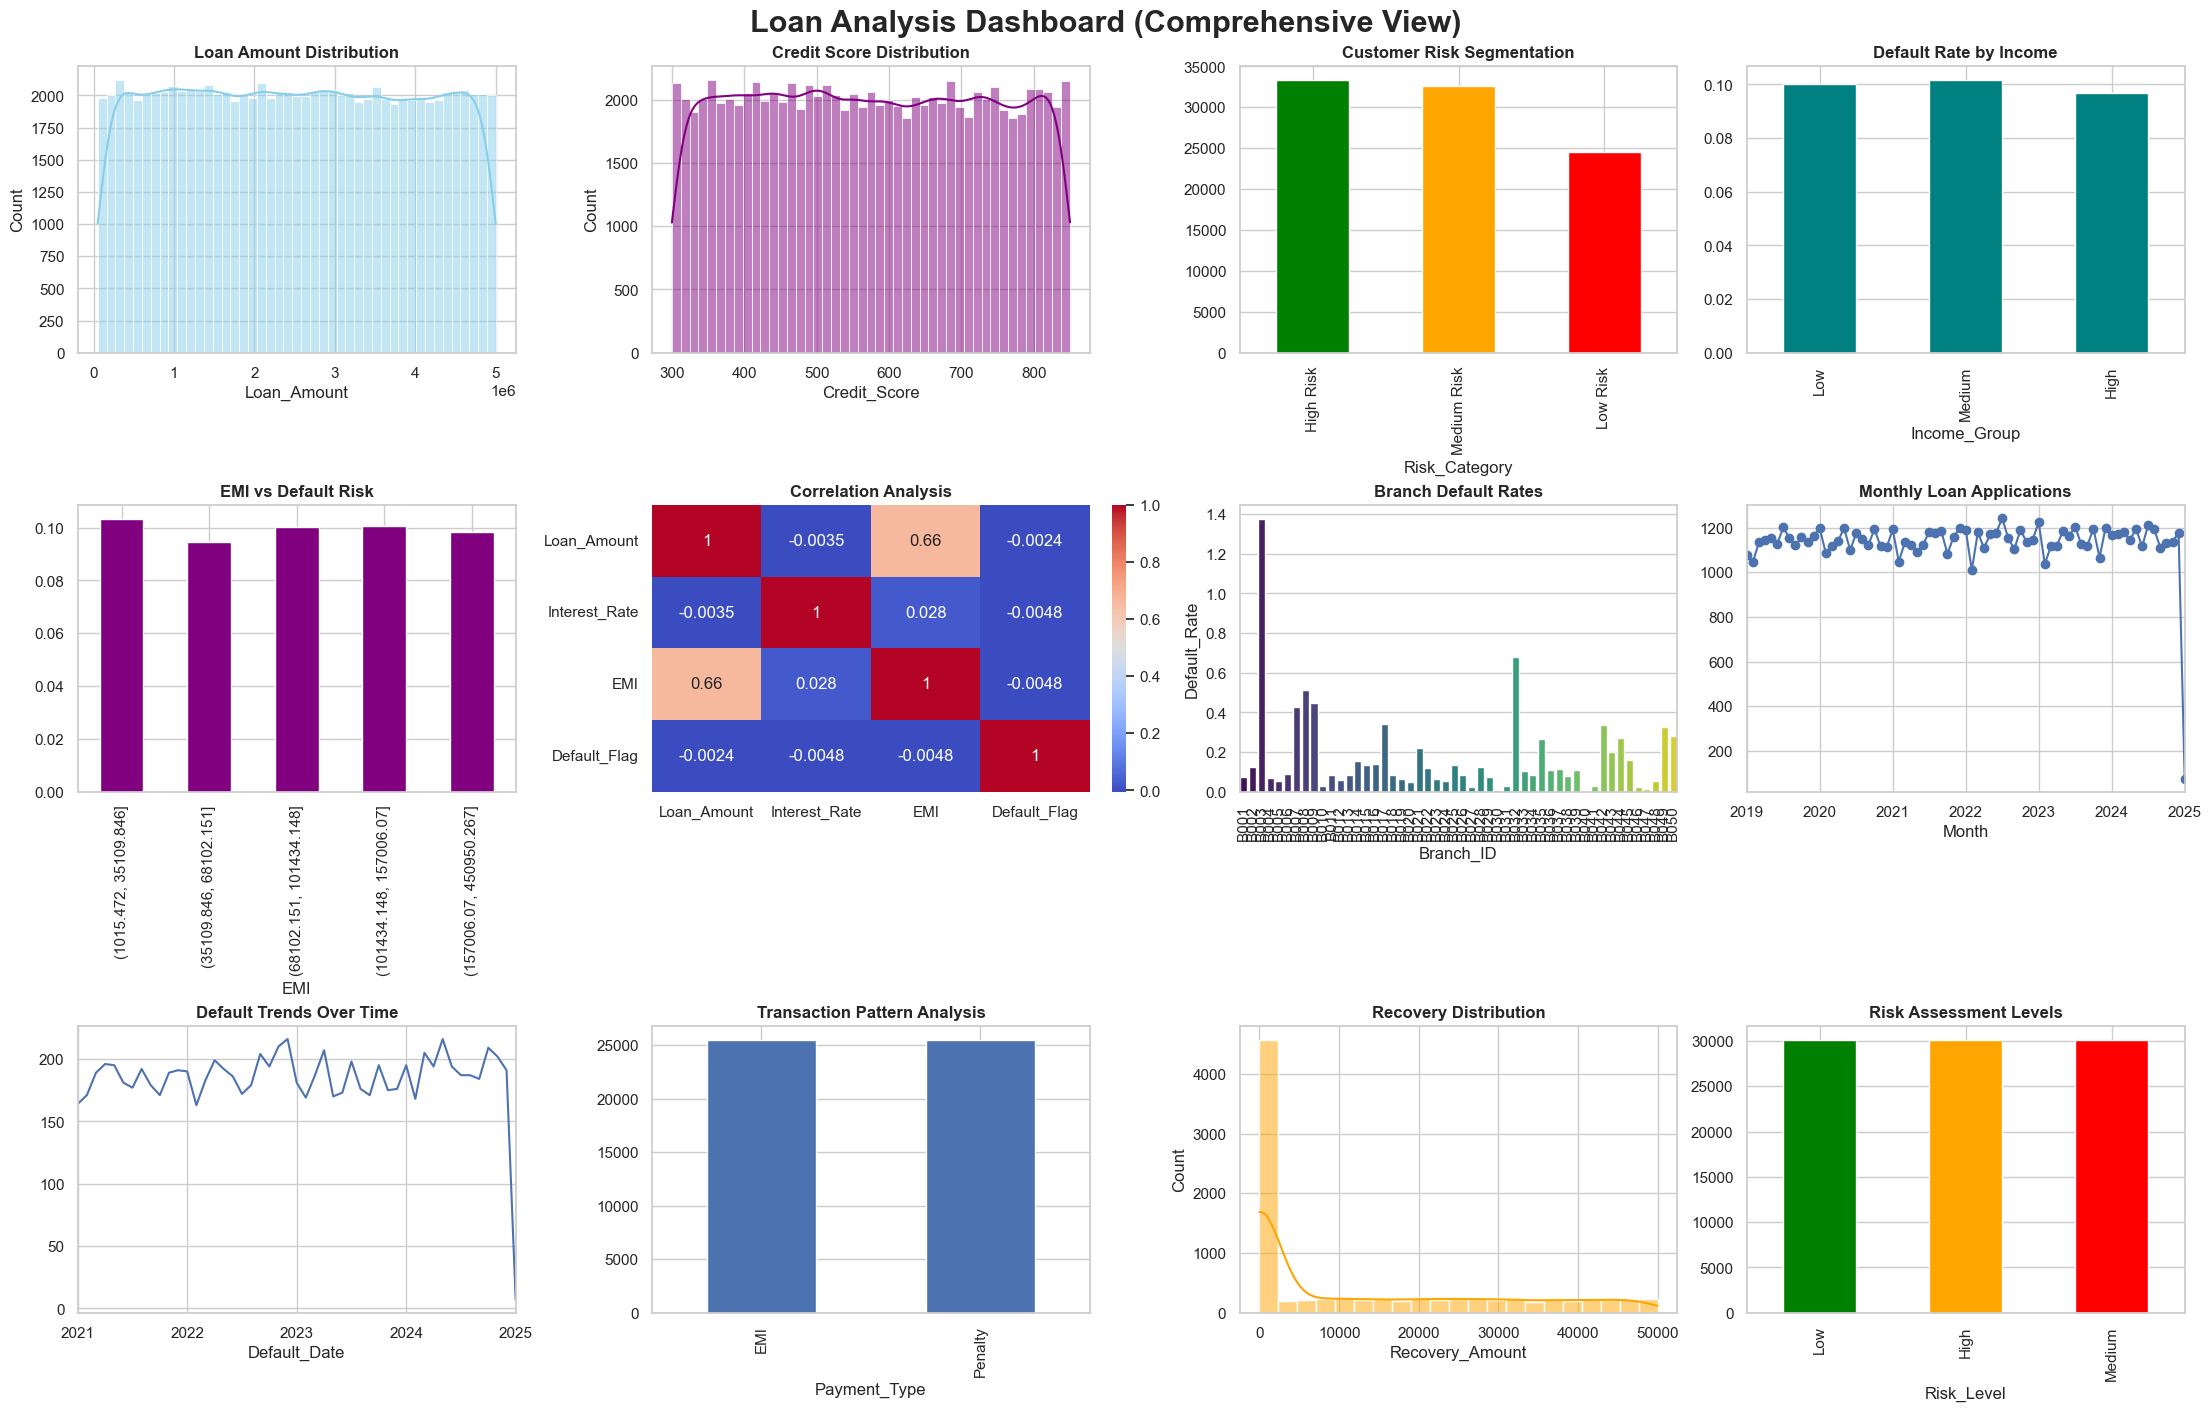

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (22, 14)

# -------------------------------
# LOAD DATA
# -------------------------------
customers = pd.read_csv(r"C:\Users\sikak\OneDrive\Desktop\notes\hero vired\assignment-1\customers.csv")
loans = pd.read_csv(r"C:\Users\sikak\OneDrive\Desktop\notes\hero vired\assignment-1\loans.csv")
transactions = pd.read_csv(r"C:\Users\sikak\OneDrive\Desktop\notes\hero vired\assignment-1\transactions.csv")
defaults = pd.read_csv(r"C:\Users\sikak\OneDrive\Desktop\notes\hero vired\assignment-1\defaults.csv")
branches = pd.read_csv(r"C:\Users\sikak\OneDrive\Desktop\notes\hero vired\assignment-1\branches.csv")
applications = pd.read_csv(r"C:\Users\sikak\OneDrive\Desktop\notes\hero vired\assignment-1\applications.csv", low_memory=False)

# -------------------------------
# CLEANING
# -------------------------------
for df in [customers, loans, transactions, defaults, branches, applications]:
    df.columns = df.columns.str.strip()

customers.ffill(inplace=True)
loans.fillna(0, inplace=True)
defaults.fillna(0, inplace=True)

applications['Application_Date'] = pd.to_datetime(applications['Application_Date'], errors='coerce')
transactions['Transaction_Date'] = pd.to_datetime(transactions['Transaction_Date'], errors='coerce')
defaults['Default_Date'] = pd.to_datetime(defaults['Default_Date'], errors='coerce')

# -------------------------------
# MERGE
# -------------------------------
data = loans.merge(customers, on="Customer_ID", how="left")
data = data.merge(defaults, on="Loan_ID", how="left")

data['Default_Amount'] = data['Default_Amount'].fillna(0)
data['Default_Flag'] = (data['Default_Amount'] > 0).astype(int)

# -------------------------------
# ADD REQUIRED FEATURES
# -------------------------------

# EMI
r = data['Interest_Rate'] / (12 * 100)
n = data['Loan_Term']
data['EMI'] = (data['Loan_Amount'] * r * (1 + r)**n) / ((1 + r)**n - 1)

# Risk Category
data['Risk_Category'] = data['Credit_Score'].apply(
    lambda x: "Low Risk" if x > 700 else ("Medium Risk" if x > 500 else "High Risk")
)

# Income Group
data['Income_Group'] = pd.qcut(data['Annual_Income'], 3, labels=['Low','Medium','High'])

# Risk Score + Level
data['Risk_Score'] = data['Loan_Amount'] * data['Interest_Rate'] / data['Credit_Score']
data['Risk_Level'] = pd.qcut(data['Risk_Score'], 3, labels=['Low','Medium','High'])

# Branch Performance
branch_perf = branches.copy()
branch_perf['Default_Rate'] = branch_perf['Delinquent_Loans'] / branch_perf['Total_Active_Loans']

# Monthly Applications
applications['Month'] = applications['Application_Date'].dt.to_period('M')
monthly_apps = applications.groupby('Month').size()

# Default Trend
default_trend = defaults.groupby(defaults['Default_Date'].dt.to_period('M')).size()

# -------------------------------
# DASHBOARD
# -------------------------------
fig = plt.figure(constrained_layout=True)
gs = fig.add_gridspec(3, 4)

# 1
ax1 = fig.add_subplot(gs[0, 0])
sns.histplot(data['Loan_Amount'], kde=True, ax=ax1, color='skyblue')
ax1.set_title("Loan Amount Distribution", weight='bold')

# 2
ax2 = fig.add_subplot(gs[0, 1])
sns.histplot(data['Credit_Score'], kde=True, ax=ax2, color='purple')
ax2.set_title("Credit Score Distribution", weight='bold')

# 3
ax3 = fig.add_subplot(gs[0, 2])
data['Risk_Category'].value_counts().plot(kind='bar', ax=ax3,
                                          color=['green','orange','red'])
ax3.set_title("Customer Risk Segmentation", weight='bold')

# 4
ax4 = fig.add_subplot(gs[0, 3])
income_default = data.groupby('Income_Group', observed=True)['Default_Flag'].mean()
income_default.plot(kind='bar', ax=ax4, color='teal')
ax4.set_title("Default Rate by Income", weight='bold')

# 5 (YOUR UPDATED EMI VERSION ✅)
ax5 = fig.add_subplot(gs[1, 0])
emi_bins = pd.qcut(data['EMI'], 5)
emi_default = data.groupby(emi_bins, observed=True)['Default_Flag'].mean()
emi_default.plot(kind='bar', ax=ax5, color='purple')
ax5.set_title("EMI vs Default Risk", weight='bold')

# 6
ax6 = fig.add_subplot(gs[1, 1])
sns.heatmap(data[['Loan_Amount','Interest_Rate','EMI','Default_Flag']].corr(),
            annot=True, cmap='coolwarm', ax=ax6)
ax6.set_title("Correlation Analysis", weight='bold')

# 7
ax7 = fig.add_subplot(gs[1, 2])
sns.barplot(x=branch_perf['Branch_ID'], y=branch_perf['Default_Rate'],
            hue=branch_perf['Branch_ID'], legend=False,
            palette='viridis', ax=ax7)
ax7.tick_params(axis='x', rotation=90)
ax7.set_title("Branch Default Rates", weight='bold')

# 8
ax8 = fig.add_subplot(gs[1, 3])
monthly_apps.plot(marker='o', ax=ax8)
ax8.set_title("Monthly Loan Applications", weight='bold')

# 9
ax9 = fig.add_subplot(gs[2, 0])
default_trend.plot(ax=ax9)
ax9.set_title("Default Trends Over Time", weight='bold')

# 10
ax10 = fig.add_subplot(gs[2, 1])
transactions.groupby('Payment_Type')['Amount'].mean().plot(kind='bar', ax=ax10)
ax10.set_title("Transaction Pattern Analysis", weight='bold')

# 11
ax11 = fig.add_subplot(gs[2, 2])
sns.histplot(defaults['Recovery_Amount'], kde=True, ax=ax11, color='orange')
ax11.set_title("Recovery Distribution", weight='bold')

# 12
ax12 = fig.add_subplot(gs[2, 3])
data['Risk_Level'].value_counts().plot(kind='bar', ax=ax12,
                                       color=['green','orange','red'])
ax12.set_title("Risk Assessment Levels", weight='bold')

fig.suptitle("Loan Analysis Dashboard (Comprehensive View)", 
             fontsize=22, weight='bold')

plt.show()